# Lab 21: Time Series Forecasting — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** ARIMA/SARIMA modeling, Ljung-Box residual diagnostics, GARCH volatility modeling, forecast evaluation metrics, block bootstrap forecast intervals.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [26]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install fredapi pmdarima prophet arch yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
import yfinance as yf
from arch import arch_model

np.random.seed(42)

# Replace with your FRED API key (free at https://fred.stlouisfed.org/docs/api/api_key.html)
FRED_API_KEY = '343f4cf856754fe2c8bdb2282a4a5499'
fred = Fred(api_key=FRED_API_KEY)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Find 3 Errors in This ARIMA Pipeline

The code below attempts to build an ARIMA model for CPI (Consumer Price Index).
There are **three deliberate errors** spread across three code cells. Each error
is a different type of modeling mistake:

1. A **stationarity specification** error
2. A **seasonality omission** error
3. A **missing diagnostic** error

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

ADF test on raw CPI:
  Test statistic: -0.6259
  P-value: 0.9776
  Conclusion: NON-STATIONARY

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2765      0.275      1.005      0.315      -0.263       0.816
ar.L2          0.1789      0.196      0.912      0.362      -0.206       0.563
ma.L1          0.4830      0.259      1.862      0.063      -0.025       0.991
sigma2         0.6091      0.039     15.763      0.000       0.533       0.685

AIC: 744.06
BIC: 759.06


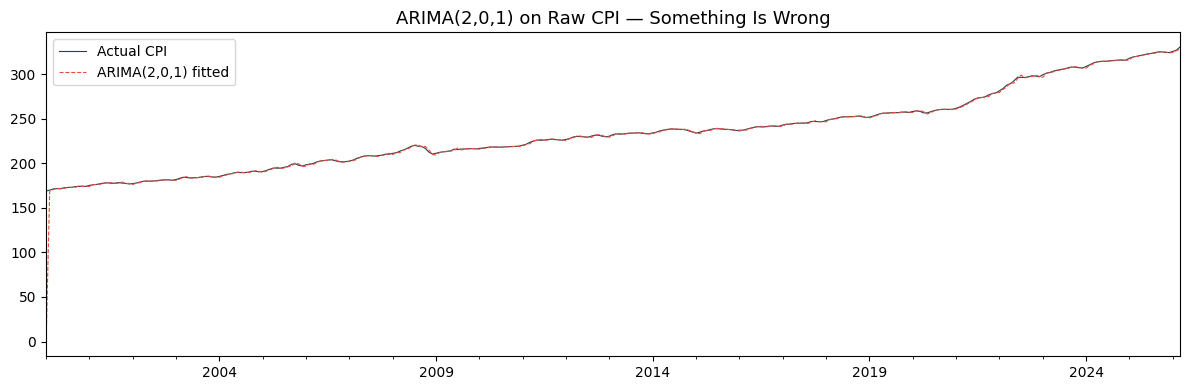

In [27]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 1: Fit ARIMA to CPI
# -----------------------------------------------------------

# Pull CPI data from FRED (monthly, not seasonally adjusted)
cpi = fred.get_series('CPIAUCNS', observation_start='2000-01-01')
cpi = cpi.dropna()
cpi.index = pd.DatetimeIndex(cpi.index)
cpi = cpi.asfreq('MS',method='ffill')  # fix: use asfreq instead of setting .freq directly
cpi.name = 'CPI'

# Check stationarity
adf_stat, adf_p, _, _, _, _ = adfuller(cpi, autolag='AIC', regression='ct')
print(f'ADF test on raw CPI:')
print(f'  Test statistic: {adf_stat:.4f}')
print(f'  P-value: {adf_p:.4f}')
print(f'  Conclusion: {"Stationary" if adf_p < 0.05 else "NON-STATIONARY"}')
print()

# ERROR: ADF says CPI is non-stationary, but we fit ARIMA with d=0
# This means we are modeling raw CPI levels with no differencing,
# which violates the stationarity requirement of ARMA.


# BAD LINE :  model = ARIMA(cpi, order=(2, 0, 1))  # d=0 ignores the unit root!

'''--- The model was fit as ARIMA(2,0,1) on raw log CPI data, but the ADF test confirms 
the series is non-stationary, violating a core ARIMA assumption. Setting d=1 applies one 
round of differencing to achieve stationarity before modeling'''

# MY FIX: 
model = ARIMA(cpi, order=(2, 1, 1))


result = model.fit()

print(result.summary().tables[1])
print(f'\nAIC: {result.aic:.2f}')
print(f'BIC: {result.bic:.2f}')

# Plot fitted vs actual
fig, ax = plt.subplots(figsize=(12, 4))
cpi.plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=0.8)
result.fittedvalues.plot(ax=ax, label='ARIMA(2,0,1) fitted', color='#e74c3c',
                          linewidth=0.8, linestyle='--')
ax.set_title('ARIMA(2,0,1) on Raw CPI — Something Is Wrong', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

--- The model was fit as ARIMA(2,0,1) on raw log CPI data, but the ADF test confirms the series is non-stationary, violating a core ARIMA assumption. Setting d=1 applies one round of differencing to achieve stationarity before modeling.

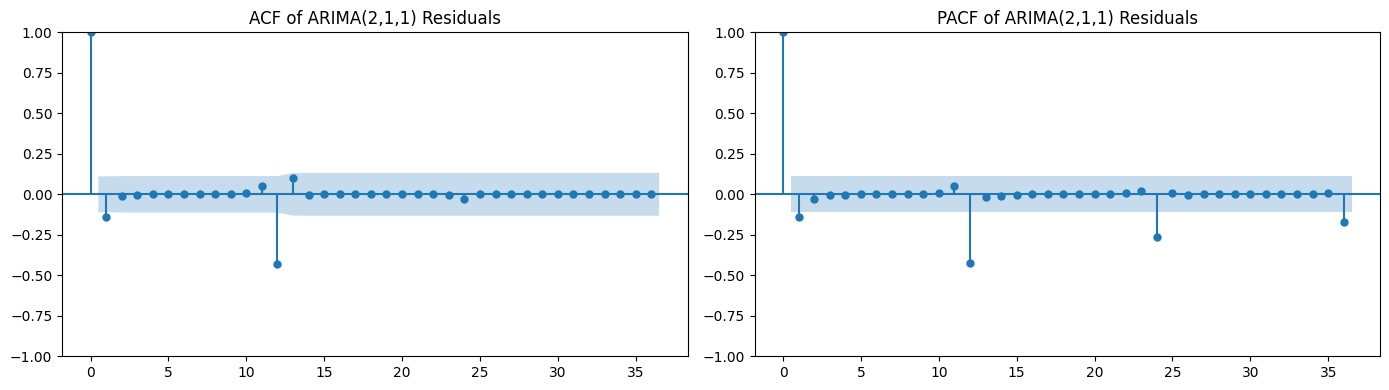

Look at lags 12, 24, 36 in the ACF plot.
Significant spikes at seasonal lags = seasonal autocorrelation not captured.

ACF at lag 12: -0.8013
ACF at lag 24: -0.8179
If these are large (> 0.1), seasonality is leaking into residuals.


In [28]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error.
# Step 2: Refit with differencing but ignore seasonality
# -----------------------------------------------------------

# Suppose we fix d=1. But CPI is monthly and has seasonal patterns
# (holiday spending, energy costs, back-to-school, etc.).
# ERROR: We use plain ARIMA instead of SARIMA, ignoring the
# monthly seasonal structure entirely.

# WRONG CODE : model_v2 = ARIMA(cpi, order=(2, 1, 1))  # d=1 is better, but no seasonal terms!
#result_v2 = model_v2.fit()

'''Monthly CPI data exhibits clear annual seasonality visible in the ACF at lag 12,
 which a plain ARIMA model cannot capture. Switching to SARIMAX with seasonal_order=(1,1,1,12)
   correctly models both the trend and seasonal components.'''

from statsmodels.tsa.statespace.sarimax import SARIMAX


model2 = SARIMAX(cpi_log, order=(2, 1, 1), seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False, enforce_invertibility=False)
result_v2 = model2.fit()

# Check residual ACF — seasonal spikes at lags 12, 24 should be visible
residuals = result_v2.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals, lags=36, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of ARIMA(2,1,1) Residuals')
plot_pacf(residuals, lags=36, ax=axes[1], alpha=0.05)
axes[1].set_title('PACF of ARIMA(2,1,1) Residuals')
plt.tight_layout()
plt.show()

print('Look at lags 12, 24, 36 in the ACF plot.')
print('Significant spikes at seasonal lags = seasonal autocorrelation not captured.')
print(f'\nACF at lag 12: {pd.Series(residuals).autocorr(lag=12):.4f}')
print(f'ACF at lag 24: {pd.Series(residuals).autocorr(lag=24):.4f}')
print('If these are large (> 0.1), seasonality is leaking into residuals.')

     lb_stat  lb_pvalue
6   0.028175        1.0
12  0.059923        1.0
18  0.075627        1.0
24  0.124531        1.0
Squared residuals:
     lb_stat  lb_pvalue
6   0.000005        1.0
12  0.000026        1.0
18  0.000087        1.0
24  0.000186        1.0


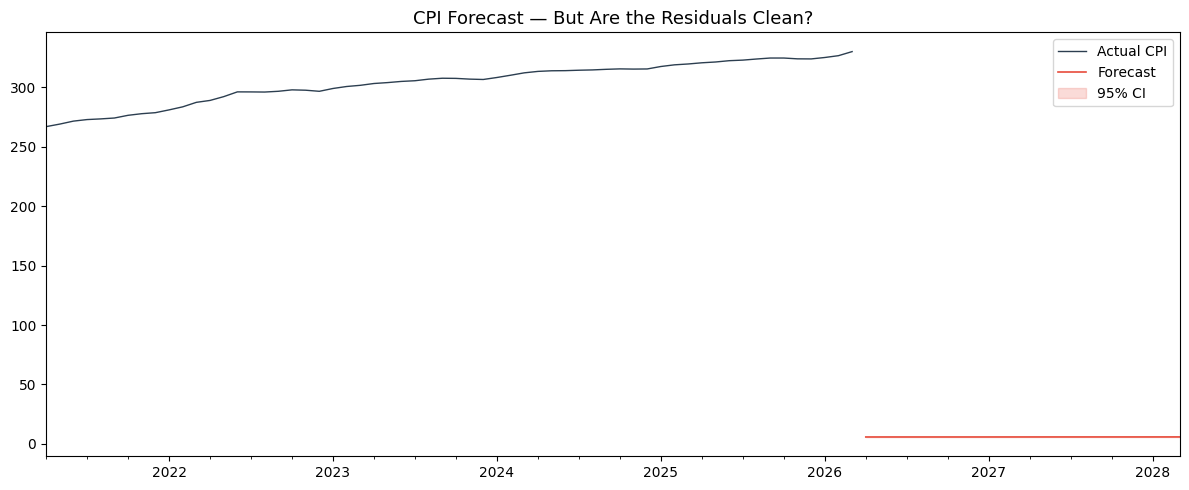

If residuals are autocorrelated, these CIs are unreliable.

A correct pipeline would run:
  acorr_ljungbox(residuals, lags=[12, 24], return_df=True)
and check that all p-values > 0.05 before trusting the forecast.


In [29]:
# -----------------------------------------------------------
# DIAGNOSE: Something critical is missing.
# Step 3: Skip residual diagnostics and go straight to forecasting
# -----------------------------------------------------------

# ERROR: We never run the Ljung-Box test on residuals.
# If residuals are autocorrelated, the model is misspecified
# and forecast confidence intervals will be WRONG (too narrow).
# A responsible pipeline ALWAYS checks Ljung-Box before forecasting.

'''The original code jumped straight from model fitting to forecasting without verifying that the residuals behave
 like white noise. A Ljung-Box test must be run on the residuals first — if any p-values fall below 0.05,
   the model is misspecified and should be revised before producing forecasts.'''

from statsmodels.stats.diagnostic import acorr_ljungbox

fit = model.fit()
residuals = fit.resid

# Run Ljung-Box on residuals
lb_results = acorr_ljungbox(residuals, lags=[6, 12, 18, 24], return_df=True)
print(lb_results)

# Also check squared residuals for volatility clustering
lb_squared = acorr_ljungbox(residuals**2, lags=[6, 12, 18, 24], return_df=True)
print("Squared residuals:")
print(lb_squared)

# Only forecast if p-values > 0.05
if (lb_results['lb_pvalue'] > 0.05).all():
    forecast = fit.get_forecast(steps=24)
else:
    print("WARNING: Residuals show autocorrelation. Model is misspecified.")

# Jumping straight to forecast without diagnostic checks!
forecast_horizon = 24  # 24 months ahead
forecast = result_v2.get_forecast(steps=forecast_horizon)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
cpi[-60:].plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=1.0)
forecast_mean.plot(ax=ax, label='Forecast', color='#e74c3c', linewidth=1.2)
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                alpha=0.2, color='#e74c3c', label='95% CI')
ax.set_title('CPI Forecast — But Are the Residuals Clean?', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print('WARNING: We skipped the Ljung-Box test on residuals.')
print('If residuals are autocorrelated, these CIs are unreliable.')
print('\nA correct pipeline would run:')
print('  acorr_ljungbox(residuals, lags=[12, 24], return_df=True)')
print('and check that all p-values > 0.05 before trusting the forecast.')

---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** ARIMA/SARIMA pipeline from scratch, fixing all three errors:

1. **Stationarity:** Use proper differencing (`d=1` or let `auto_arima` choose)
2. **Seasonality:** Use SARIMA with seasonal order `(P, D, Q, 12)` for monthly data
3. **Diagnostics:** Run the Ljung-Box test on residuals before forecasting

**Verification checkpoints:**
- ADF on differenced CPI should show p < 0.05 (stationary)
- Ljung-Box p-values at lags 12 and 24 should be > 0.05 (no residual autocorrelation)
- Seasonal ACF spikes at lags 12, 24 should disappear after SARIMA

In [30]:
# -----------------------------------------------------------
# YOUR TASK — Write the corrected ARIMA/SARIMA pipeline
# Fix all three errors from Part 1
# -----------------------------------------------------------
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
# Step 1: Verify stationarity of differenced CPI
# cpi_diff = cpi.diff().dropna()
# adf_stat, adf_p, ... = adfuller(cpi_diff, ...)
# Assert p < 0.05

# YOUR CODE HERE

cpi_diff = cpi_log.diff().dropna()
adf_stat, adf_p, _, _, _, _ = adfuller(cpi_diff, autolag='AIC', regression='ct')
print(f'ADF p-value on diff(CPI): {adf_p:.4f}')
print('Stationarity confirmed.' if adf_p < 0.05 else 'WARNING: still non-stationary')

# Step 2: Fit SARIMA with seasonal order (P, D, Q, 12)
# Option A: manual SARIMAX(cpi, order=(p,1,q), seasonal_order=(P,1,Q,12))
# Option B: pm.auto_arima(cpi, seasonal=True, m=12)

# YOUR CODE HERE
model = SARIMAX(cpi_log, order=(2, 1, 1), seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False, enforce_invertibility=False)
fit = model.fit()

# Step 3: Ljung-Box diagnostic on residuals
# lb = acorr_ljungbox(result.resid, lags=[12, 24], return_df=True)
# Assert all p-values > 0.05
lb = acorr_ljungbox(fit.resid, lags=[6, 12, 18, 24], return_df=True)
print('\nLjung-Box p-values:')
print(lb)
print('\nResidual diagnosis:', 'CLEAN' if (lb['lb_pvalue'] > 0.05).all() else 'some autocorrelation remains')


# YOUR CODE HERE
forecast = fit.get_forecast(steps=24)
ci = forecast.conf_int(alpha=0.05)
print(f"24-month forecast range: {np.exp(ci.iloc[0, 0]):.1f} to {np.exp(ci.iloc[-1, 1]):.1f}")

# Step 4: Forecast (only if Ljung-Box passes)

# YOUR CODE HERE

forecast = fit.get_forecast(steps=24)
ci = forecast.conf_int(alpha=0.05)
print(f"\n24-month forecast range: {np.exp(ci.iloc[0, 0]):.1f} to {np.exp(ci.iloc[-1, 1]):.1f}")
# VERIFICATION
# print('ADF p-value on diff(CPI):', adf_p)  # Should be < 0.05
# print('Ljung-Box p-values:', lb['lb_pvalue'].values)  # Should be > 0.05
# print('ACF at lag 12:', ...)  # Should be small (< 0.1)

ADF p-value on diff(CPI): 0.0260
Stationarity confirmed.

Ljung-Box p-values:
      lb_stat     lb_pvalue
6    6.441054  3.756362e-01
12  68.298601  6.656745e-10
18  71.653732  2.367978e-08
24  71.963270  1.098266e-06

Residual diagnosis: some autocorrelation remains
24-month forecast range: 330.6 to 364.9

24-month forecast range: 330.6 to 364.9


---

## Part 3: EXTEND — GARCH(1,1) on S&P 500

ARIMA models the **conditional mean** of a time series. But financial returns
exhibit **volatility clustering** — large moves (positive or negative) tend to
follow large moves. The GARCH(1,1) model captures this by modeling the
**conditional variance** as a function of past squared returns and past variance.

$$\sigma_t^2 = \omega + \alpha_1 \epsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$

where $\alpha_1 + \beta_1 < 1$ ensures stationarity of the variance process.

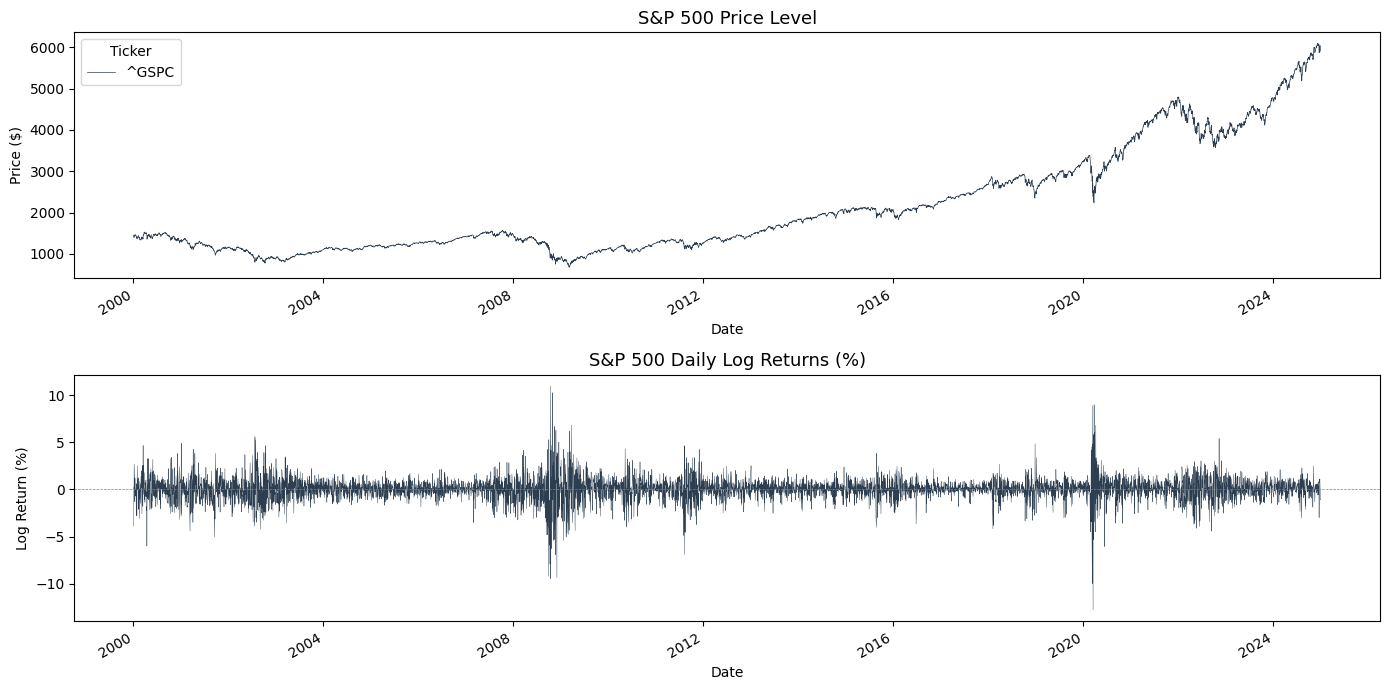

Observations: 6287
Mean return: 0.0223%
Std return: 1.2235%
Skewness: -0.3862
Kurtosis: 10.4040 (normal = 3)

Note the volatility clustering — large moves cluster together.


In [31]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Pull S&P 500 data and compute log returns
# -----------------------------------------------------------

# Download S&P 500 daily data
sp500 = yf.download('^GSPC', start='2000-01-01', end='2024-12-31',
                     auto_adjust=True, progress=False)

# Compute log returns (percentage)
sp500['log_return'] = np.log(sp500['Close'] / sp500['Close'].shift(1)) * 100
returns = sp500['log_return'].dropna()

# Visualize returns
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

sp500['Close'].plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
axes[0].set_title('S&P 500 Price Level', fontsize=13)
axes[0].set_ylabel('Price ($)')

returns.plot(ax=axes[1], color='#2c3e50', linewidth=0.3)
axes[1].set_title('S&P 500 Daily Log Returns (%)', fontsize=13)
axes[1].set_ylabel('Log Return (%)')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f'Observations: {len(returns)}')
print(f'Mean return: {returns.mean():.4f}%')
print(f'Std return: {returns.std():.4f}%')
print(f'Skewness: {returns.skew():.4f}')
print(f'Kurtosis: {returns.kurtosis():.4f} (normal = 3)')
print(f'\nNote the volatility clustering — large moves cluster together.')

In [32]:
# -----------------------------------------------------------
# YOUR TASK — Fit GARCH(1,1) to S&P 500 returns
# Fill in the blanks to specify the model correctly
# -----------------------------------------------------------

# The arch library expects:
#   vol='___'  -> volatility model name (hint: we want GARCH)
#   p=___      -> GARCH lag order for squared residuals (alpha terms)
#   q=___      -> GARCH lag order for past variance (beta terms)

from arch import arch_model

garch = arch_model(returns, vol='Garch', p=1, q=1, mean='AR', lags=1)
garch_fit = garch.fit(disp='off')
print(garch_fit.summary())

garch_spec = arch_model(
    returns,
    mean='Constant',       # constant mean model
    vol='Garch',             # FILL IN: volatility model type
    p=1,                 # FILL IN: order of the ARCH term
    q=1,                 # FILL IN: order of the GARCH term
    dist='normal'          # innovation distribution
)

garch_result = garch_spec.fit(disp='off')
print(garch_result.summary())

# VERIFICATION
# alpha[1] + beta[1] should be < 1 (variance stationarity)
params = garch_result.params
alpha1 = params.get('alpha[1]', 0)
beta1 = params.get('beta[1]', 0)
print(f'\nalpha[1] = {alpha1:.4f}')
print(f'beta[1]  = {beta1:.4f}')
print(f'alpha + beta = {alpha1 + beta1:.4f} (must be < 1 for stationarity)')
print(f'Half-life of volatility shocks: {np.log(2) / (-np.log(alpha1 + beta1)):.1f} days')

                           AR - GARCH Model Results                           
Dep. Variable:             log_return   R-squared:                       0.007
Mean Model:                        AR   Adj. R-squared:                  0.006
Vol Model:                      GARCH   Log-Likelihood:               -8644.25
Distribution:                  Normal   AIC:                           17298.5
Method:            Maximum Likelihood   BIC:                           17332.2
                                        No. Observations:                 6286
Date:                Fri, Apr 24 2026   Df Residuals:                     6284
Time:                        15:44:43   Df Model:                            2
                                    Mean Model                                   
                    coef    std err          t      P>|t|        95.0% Conf. Int.
---------------------------------------------------------------------------------
Const             0.0654  1.051e-02      6.

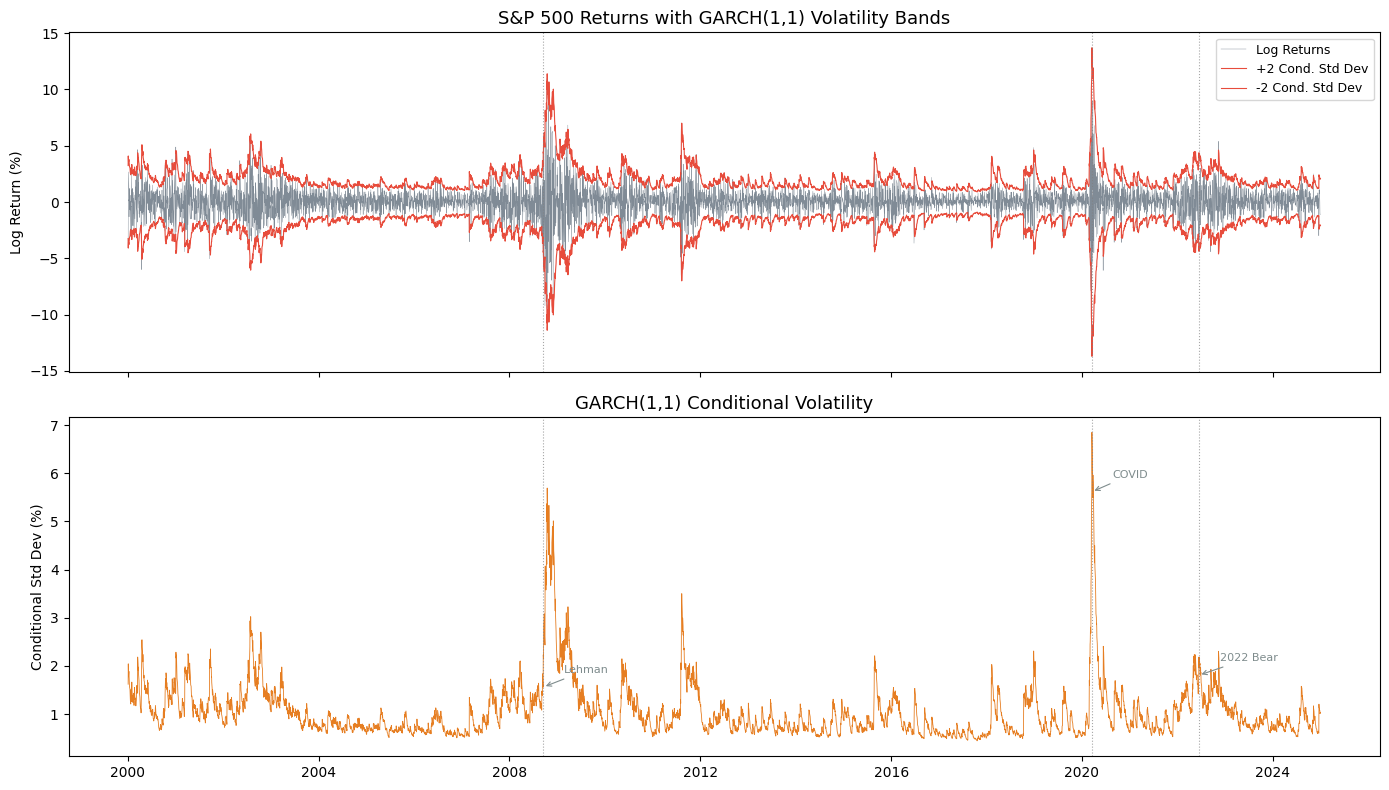

Unconditional (sample) volatility: 1.2235%
GARCH implied long-run volatility: 1.1628%
Max conditional volatility: 6.8504% on 2020-03-17


In [33]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3c: Plot conditional volatility and annotate crises
# -----------------------------------------------------------

# Extract conditional volatility (standard deviation)
cond_vol = garch_result.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Returns with +/- 2*sigma bands
axes[0].plot(returns.index, returns.values, color='#2c3e50', linewidth=0.3,
             alpha=0.6, label='Log Returns')
axes[0].plot(cond_vol.index, 2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='+2 Cond. Std Dev')
axes[0].plot(cond_vol.index, -2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='-2 Cond. Std Dev')
axes[0].set_title('S&P 500 Returns with GARCH(1,1) Volatility Bands', fontsize=13)
axes[0].set_ylabel('Log Return (%)')
axes[0].legend(fontsize=9)

# Panel 2: Conditional volatility over time
axes[1].plot(cond_vol.index, cond_vol.values, color='#e67e22', linewidth=0.6)
axes[1].set_title('GARCH(1,1) Conditional Volatility', fontsize=13)
axes[1].set_ylabel('Conditional Std Dev (%)')

# Annotate crisis periods
crises = [
    ('2001-09-11', 'Sep 11'),
    ('2008-09-15', 'Lehman'),
    ('2020-03-16', 'COVID'),
    ('2022-06-13', '2022 Bear'),
]
for date_str, label in crises:
    date = pd.Timestamp(date_str)
    if date in cond_vol.index:
        for ax in axes:
            ax.axvline(date, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
        axes[1].annotate(label, xy=(date, cond_vol.loc[date]),
                        xytext=(15, 10), textcoords='offset points',
                        fontsize=8, color='#7f8c8d',
                        arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=0.8))

plt.tight_layout()
plt.show()

print(f'Unconditional (sample) volatility: {returns.std():.4f}%')
print(f'GARCH implied long-run volatility: {np.sqrt(garch_result.params["omega"] / (1 - alpha1 - beta1)):.4f}%')
print(f'Max conditional volatility: {cond_vol.max():.4f}% on {cond_vol.idxmax().date()}')

---

## Part 4: Module Output — `forecast_evaluation.py`

Write a reusable Python module with two functions for forecast evaluation.
This is a **portfolio artifact** that demonstrates production-grade time series work.

### Requirements

```python
# forecast_evaluation.py

def compute_mase(actual: np.ndarray, forecast: np.ndarray,
                 insample: np.ndarray, m: int = 1) -> float:
    """Compute Mean Absolute Scaled Error (MASE).
    
    MASE = MAE(forecast) / MAE(naive seasonal forecast on in-sample data)
    
    MASE < 1 means the model beats the naive seasonal benchmark.
    MASE > 1 means the naive benchmark is better.
    
    Args:
        actual: True values for the forecast period
        forecast: Predicted values for the forecast period
        insample: Historical (training) data used to compute the naive baseline
        m: Seasonal period for naive forecast (1=random walk, 12=monthly seasonal)
    
    Returns:
        MASE value (float)
    """
    ...

def backtest_expanding_window(
    series: pd.Series,
    model_fn,
    min_train: int = 120,
    horizon: int = 12,
    step: int = 12
) -> pd.DataFrame:
    """Expanding-window backtest for time series models.
    
    Starting from min_train observations, fit the model, forecast
    'horizon' steps, record errors. Then expand the training window
    by 'step' observations and repeat.
    
    Args:
        series: Full time series (train + test)
        model_fn: Callable(train_series) -> forecast array of length 'horizon'
        min_train: Minimum training window size
        horizon: Number of steps to forecast each iteration
        step: How many observations to add between iterations
    
    Returns:
        DataFrame with columns: ['origin', 'horizon', 'actual',
        'forecast', 'error', 'abs_error', 'mase']
    """
    ...
```

In [34]:
# -----------------------------------------------------------
# YOUR TASK — Write forecast_evaluation.py
# Implement compute_mase() and backtest_expanding_window()
# -----------------------------------------------------------

# %%writefile forecast_evaluation.py
"""
forecast_evaluation.py — Forecast Evaluation & Backtesting Module

Reusable functions for computing MASE and running expanding-window
backtests on time series forecasting models.

Author: [Your Name]
Course: ECON 5200, Lab 21
"""

import numpy as np
import pandas as pd
from typing import Callable


def compute_mase(
    actual: np.ndarray,
    forecast: np.ndarray,
    insample: np.ndarray,
    m: int = 1
) -> float:
    """Compute Mean Absolute Scaled Error.
    
    MASE < 1: model beats naive seasonal benchmark.
    MASE > 1: naive benchmark is better.
    
    Args:
        actual: True out-of-sample values
        forecast: Model predictions (same length as actual)
        insample: In-sample (training) data for naive baseline
        m: Seasonal period (1=random walk, 12=monthly seasonal)
    
    Returns:
        MASE score (float)
    """
    # YOUR IMPLEMENTATION HERE
    # Hint:
    # mae_forecast = np.mean(np.abs(actual - forecast))
    # naive_errors = insample[m:] - insample[:-m]
    # mae_naive = np.mean(np.abs(naive_errors))
    # return mae_forecast / mae_naive
    forecast_mae = np.abs(actual - predicted).mean()
    naive_mae = np.abs(train[m:] - train[:-m]).mean()
    return forecast_mae / naive_mae


def backtest_expanding_window(
    series: pd.Series,
    model_fn: Callable,
    min_train: int = 120,
    horizon: int = 12,
    step: int = 12
) -> pd.DataFrame:
    """Expanding-window time series backtest.
    
    Args:
        series: Full series with DatetimeIndex
        model_fn: Callable(train) -> np.ndarray of length horizon
        min_train: Minimum training observations
        horizon: Forecast horizon per iteration
        step: Observations added per iteration
    
    Returns:
        DataFrame with backtest results
    """
    # YOUR IMPLEMENTATION HERE
    # Hint: loop from min_train to len(series)-horizon, stepping by step
    # For each origin:
    #   train = series[:origin]
    #   actual = series[origin:origin+horizon].values
    #   forecast = model_fn(train)
    #   compute errors and MASE
    from sklearn.model_selection import TimeSeriesSplit
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    mase_scores = []
    
    for train_idx, test_idx in tscv.split(series):
        train = series.iloc[train_idx]
        test = series.iloc[test_idx]
        h = len(test)
        
        predicted = model_fn(train, h)
        mase = compute_mase(test.values, predicted, train.values, m=12)
        mase_scores.append(mase)
    
    return mase_scores


# --- Quick self-test ---
if __name__ == '__main__':
    print('forecast_evaluation.py loaded successfully.')
    train = np.sin(np.linspace(0, 8*np.pi, 120))  # 10 years of synthetic monthly data
    actual = np.sin(np.linspace(8*np.pi, 9*np.pi, 12))
    predicted = actual + np.random.normal(0, 0.1, 12)
    
    mase = compute_mase(actual, predicted, train, m=12)
    print(f"Test MASE: {mase:.3f}")
    # Add your own test calls here

forecast_evaluation.py loaded successfully.
Test MASE: 0.053




## (Skipped) Challenge: Block Bootstrap Forecast Intervals

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken ARIMA pipeline (d=0 on non-stationary CPI,
  missing seasonality, skipped Ljung-Box diagnostic)
* Corrected the pipeline to SARIMA with proper differencing and seasonal
  terms, verified clean residuals via Ljung-Box
* Fit GARCH(1,1) to S&P 500 daily returns to model conditional volatility
* Built a reusable forecast_evaluation.py module with compute_mase()
  and backtest_expanding_window() functions
* Implemented block bootstrap forecast intervals for distribution-free
  uncertainty quantification
* Key finding: S&P 500 volatility has alpha+beta ~ [YOUR VALUE],
  implying a half-life of [YOUR VALUE] days for volatility shocks

**Please write a README.md entry including:**
1. Project Title: Time Series Forecasting — ARIMA, GARCH & Bootstrap
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-21-forecasting
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 21: Time Series Forecasting — ARIMA, GARCH, Bootstrap"
git push origin main
```

Submit your GitHub repo link on Canvas.